In [290]:

library(readr)
library(tidyverse)
library(tidymodels)
library(tidyclust)
library(repr)
library(GGally)
library(janitor)
options(repr.matrix.max.rows = 6)



# ***What types of players like receiving game-related newsletter?***



# **Introduction**

Game-related newsletters are usually sent out weekly or monthly to players as a way for developers, publishers, and gaming communities to share new updates, hike up engagement with the audience, and provide a platform to build community and interaction among players. The newsletters could have something like new game releases, announcements of online game contests, or tips that can help improve a player's gameplay. They could also be used to survey players and provide valuable feedback to developers. 

We are interested in finding the best indicators of whether a player or certain groups will subscribe to a game-related newsletter. Specifically, we would like to know: Can number of hours played (played_hours) and age (Age) predict whether someone will subscribe to a game-related newsletter (subscribe variable)? We are also interested in seeing if there are any sub-groups or clusters of players formed based on age, gender, number of hours played, and level of experience.

To do this, we will use `players.csv` dataset, with data collected from 196 players. Our dataset contains 7 variables that describe each unique player: 

    - level of experience (labelled `experience`, chr type)
    - subscription to game-related (labelled `subscribe`, lgl type)
    - email stored as string of characters (labelled `hashedEmail`, chr type)
    - number of hours played(labelled `played_hours`, dbl type)
    - gender (labelled `gender`, chr type)
    - age(labelled `Age`, dbl type)

To answer our questions, we will be using a type of classification model called K-Nearest Neighbors (KNN) Classifier and clustering algorithms called K-means Clustering. We will be using KNN model to see whether age and number of hours played can  be useful predictors of whether a player will subscribe. We will be using K-means Clustering to identify any potential subgroups of players who share similar characteristics or behaviours within dataset.

# **Methods & Results**

**Read data**

Use `read_csv` to load `players_data.csv` from the `data/` folder. 

*Assign to an object called `players_data`.*

In [291]:
players_data <- read_csv("data/players.csv")

players_data

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,17
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


**Change `subscribe` column type to factor (fct)**

Because we're using `subscribe` as response variable and we're predicting for a categorical outcome (whether they will subscribe or not), we can use mutate() and as.factor() to change the type of `subscribe` column. Assign mutated data to the same name `players_data`.

In [292]:
players_data <- players_data |>
    mutate(subscribe = as.factor(subscribe))

players_data

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<fct>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,17
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


**We are only interested in `subscribe`, `played_hours`, and `Age` columns.** 

Use clean_names() to make sure all column names are lowercase. Use select() to select for the columns needed and assign your data to an object called `clean_players`. 

In [293]:
clean_players <- players_data |>
    clean_names() |>
    select(subscribe,played_hours,age)

clean_players

subscribe,played_hours,age
<fct>,<dbl>,<dbl>
TRUE,30.3,9
TRUE,3.8,17
FALSE,0.0,17
⋮,⋮,⋮
FALSE,0.0,17
FALSE,2.3,17
TRUE,0.2,NA


# **Reason for choosing KNN Classification**

Our goal is to predict whether someone will subscribe to a game-related newsletter based on age and number of hours played. Our predictor variables are age and number of hours played and our response variable is whether someone subscribes or not. We are using KNN Classification because we are predicting for a categorical outcome and it is a simple, interpretable model. It does not make strong assumptions about data or assume relationships (e.g., linearity) which is useful for us because we don't know yet whether there is a link between age, hours played and someone subscribing. 

Assumptions: 

    - We assume that players with similar age and number of hours played will behave similarly.
    - We assume that all predictors are on the same scale (so that's why we must scale our predictor variables)
    - We assume that age and number of hours played provide meaningful data and can differentiate between subscribers and non-subscribers.

Limitations:

    - Requires scaling of predictors 
    - Sensitive to noise (one bad neighbour can influence a prediction)
    - Doesn't handle imbalanced classes well

**Split the `clean_players` dataset to training dataset and testing dataset using `initial_split()`**

From the split, we will assign the training data to an object called `players_train` and testing data to an object called `players_test`.

In [294]:
set.seed(2019)

players_split <- initial_split(clean_players, prop = 0.75, strata = subscribe) 
players_train <- training(players_split)   
players_test <- testing(players_split)

players_train
players_test
 

subscribe,played_hours,age
<fct>,<dbl>,<dbl>
FALSE,0,17
FALSE,0,22
FALSE,0,23
⋮,⋮,⋮
TRUE,0.0,20
TRUE,0.0,17
TRUE,0.2,NA


subscribe,played_hours,age
<fct>,<dbl>,<dbl>
TRUE,0,17
TRUE,0,19
FALSE,0,21
⋮,⋮,⋮
FALSE,0.2,17
TRUE,32.0,22
TRUE,0.1,44


**Create recipe for KNN model classifier**

Make sure to remove any rows with NA values from your training and testing dataset. In our recipe, we are using `age` and `played_hours` as our predictor variables to model the categorical outcome `subscribe`. We are also scaling and centering data to make sure all variables are on the same scale and not one is influencing the KNN model more than the other. KNN relies on distance calculations so if variables are not scaled, larger ranges can influence the model and give less meaningful results.

In [295]:
set.seed(2019)

players_train <- players_train |> drop_na()
players_test <- players_test |> drop_na()

players_recipe <- recipe(subscribe ~ played_hours + age, data = players_train) |>
                       step_scale(all_predictors()) |>
                       step_center(all_predictors())
                     

players_recipe



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 2



── Operations 

• Scaling for: all_predictors()

• Centering for: all_predictors()



In [296]:
set.seed(2019)

knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
      set_engine("kknn") |>
      set_mode("classification")
knn_spec

K-Nearest Neighbor Model Specification (classification)

Main Arguments:
  neighbors = tune()
  weight_func = rectangular

Computational engine: kknn 


**Check number of observations/rows in training dataset**

We need to know how many observations we have to know the maximum value of K we could tune for. 
Run the following code.

In [297]:
players_train

subscribe,played_hours,age
<fct>,<dbl>,<dbl>
FALSE,0,17
FALSE,0,22
FALSE,0,23
⋮,⋮,⋮
TRUE,0,17
TRUE,0,20
TRUE,0,17


**Table 1:** Summary of player subscription data (145 rows × 3 columns)

**Split training dataset to 5 folds for Cross Validation**

We're splitting the training dataset `players_training` into 5 folds. In each iteration, we train our model on 4 folds (training set) and test it on the remaining 1 fold (validation set). We repeat this process until each of the 5 folds serve as the validation set once. 

Note: We have 145 observations in the training data. Once we split this into 5 folds, each fold will have roughly 29 observations, stratified folds can have uneven sizes. 

In [298]:
set.seed(2019)

players_vfold <- vfold_cv(players_train, v = 5, strata = subscribe)
print(players_vfold)

#  5-fold cross-validation using stratification 
# A tibble: 5 × 2
  splits           id   
  <list>           <chr>
1 <split [115/30]> Fold1
2 <split [116/29]> Fold2
3 <split [116/29]> Fold3
4 <split [116/29]> Fold4
5 <split [117/28]> Fold5


**Create a tibble with K values we want our model to try** 

We don't know yet which is the best K to use. We have to make sure that we have enough observations for any K we're trying. The maximum K we can use cannot be larger than the number of observations in our training fold (116 observations combining observations from 4 folds). We will use K = 20 as our max to provide some buffer in case of any class imbalances or NA values. 

In [331]:
set.seed(2019)

k_vals <- tibble(neighbors = seq(from = 1, to = 20, by = 1))
k_vals

neighbors
<dbl>
1
2
3
⋮
18
19
20


**Finding the right K value through Cross Validation**

Create a workflow that includes cross-validation. Use the tibble of k values we made earlier `k_vals` and the training and validation folds `players_vfold` to tune for many K values. Then use collect_metrics() to gather performance statistics of model for different K values

In [332]:
set.seed(2019)

players_fit <- workflow() |>
      add_recipe(players_recipe) |>  
      add_model(knn_spec) |>
      tune_grid(resamples = players_vfold, grid = k_vals) |>
      collect_metrics()

players_fit

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.5436453,5,0.03029841,Preprocessor1_Model01
1,roc_auc,binary,0.5848485,5,0.01603107,Preprocessor1_Model01
2,accuracy,binary,0.5436453,5,0.03029841,Preprocessor1_Model02
⋮,⋮,⋮,⋮,⋮,⋮,⋮
19,roc_auc,binary,0.5951994,5,0.052352607,Preprocessor1_Model19
20,accuracy,binary,0.7311494,5,0.005037841,Preprocessor1_Model20
20,roc_auc,binary,0.5978162,5,0.031958370,Preprocessor1_Model20


In [333]:
accuracies_per_k <- players_fit|>
    filter(.metric == "accuracy")
accuracies_per_k

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.5436453,5,0.03029841,Preprocessor1_Model01
2,accuracy,binary,0.5436453,5,0.03029841,Preprocessor1_Model02
3,accuracy,binary,0.6261905,5,0.04640670,Preprocessor1_Model03
⋮,⋮,⋮,⋮,⋮,⋮,⋮
18,accuracy,binary,0.6968966,5,0.021715926,Preprocessor1_Model18
19,accuracy,binary,0.7311494,5,0.005037841,Preprocessor1_Model19
20,accuracy,binary,0.7311494,5,0.005037841,Preprocessor1_Model20


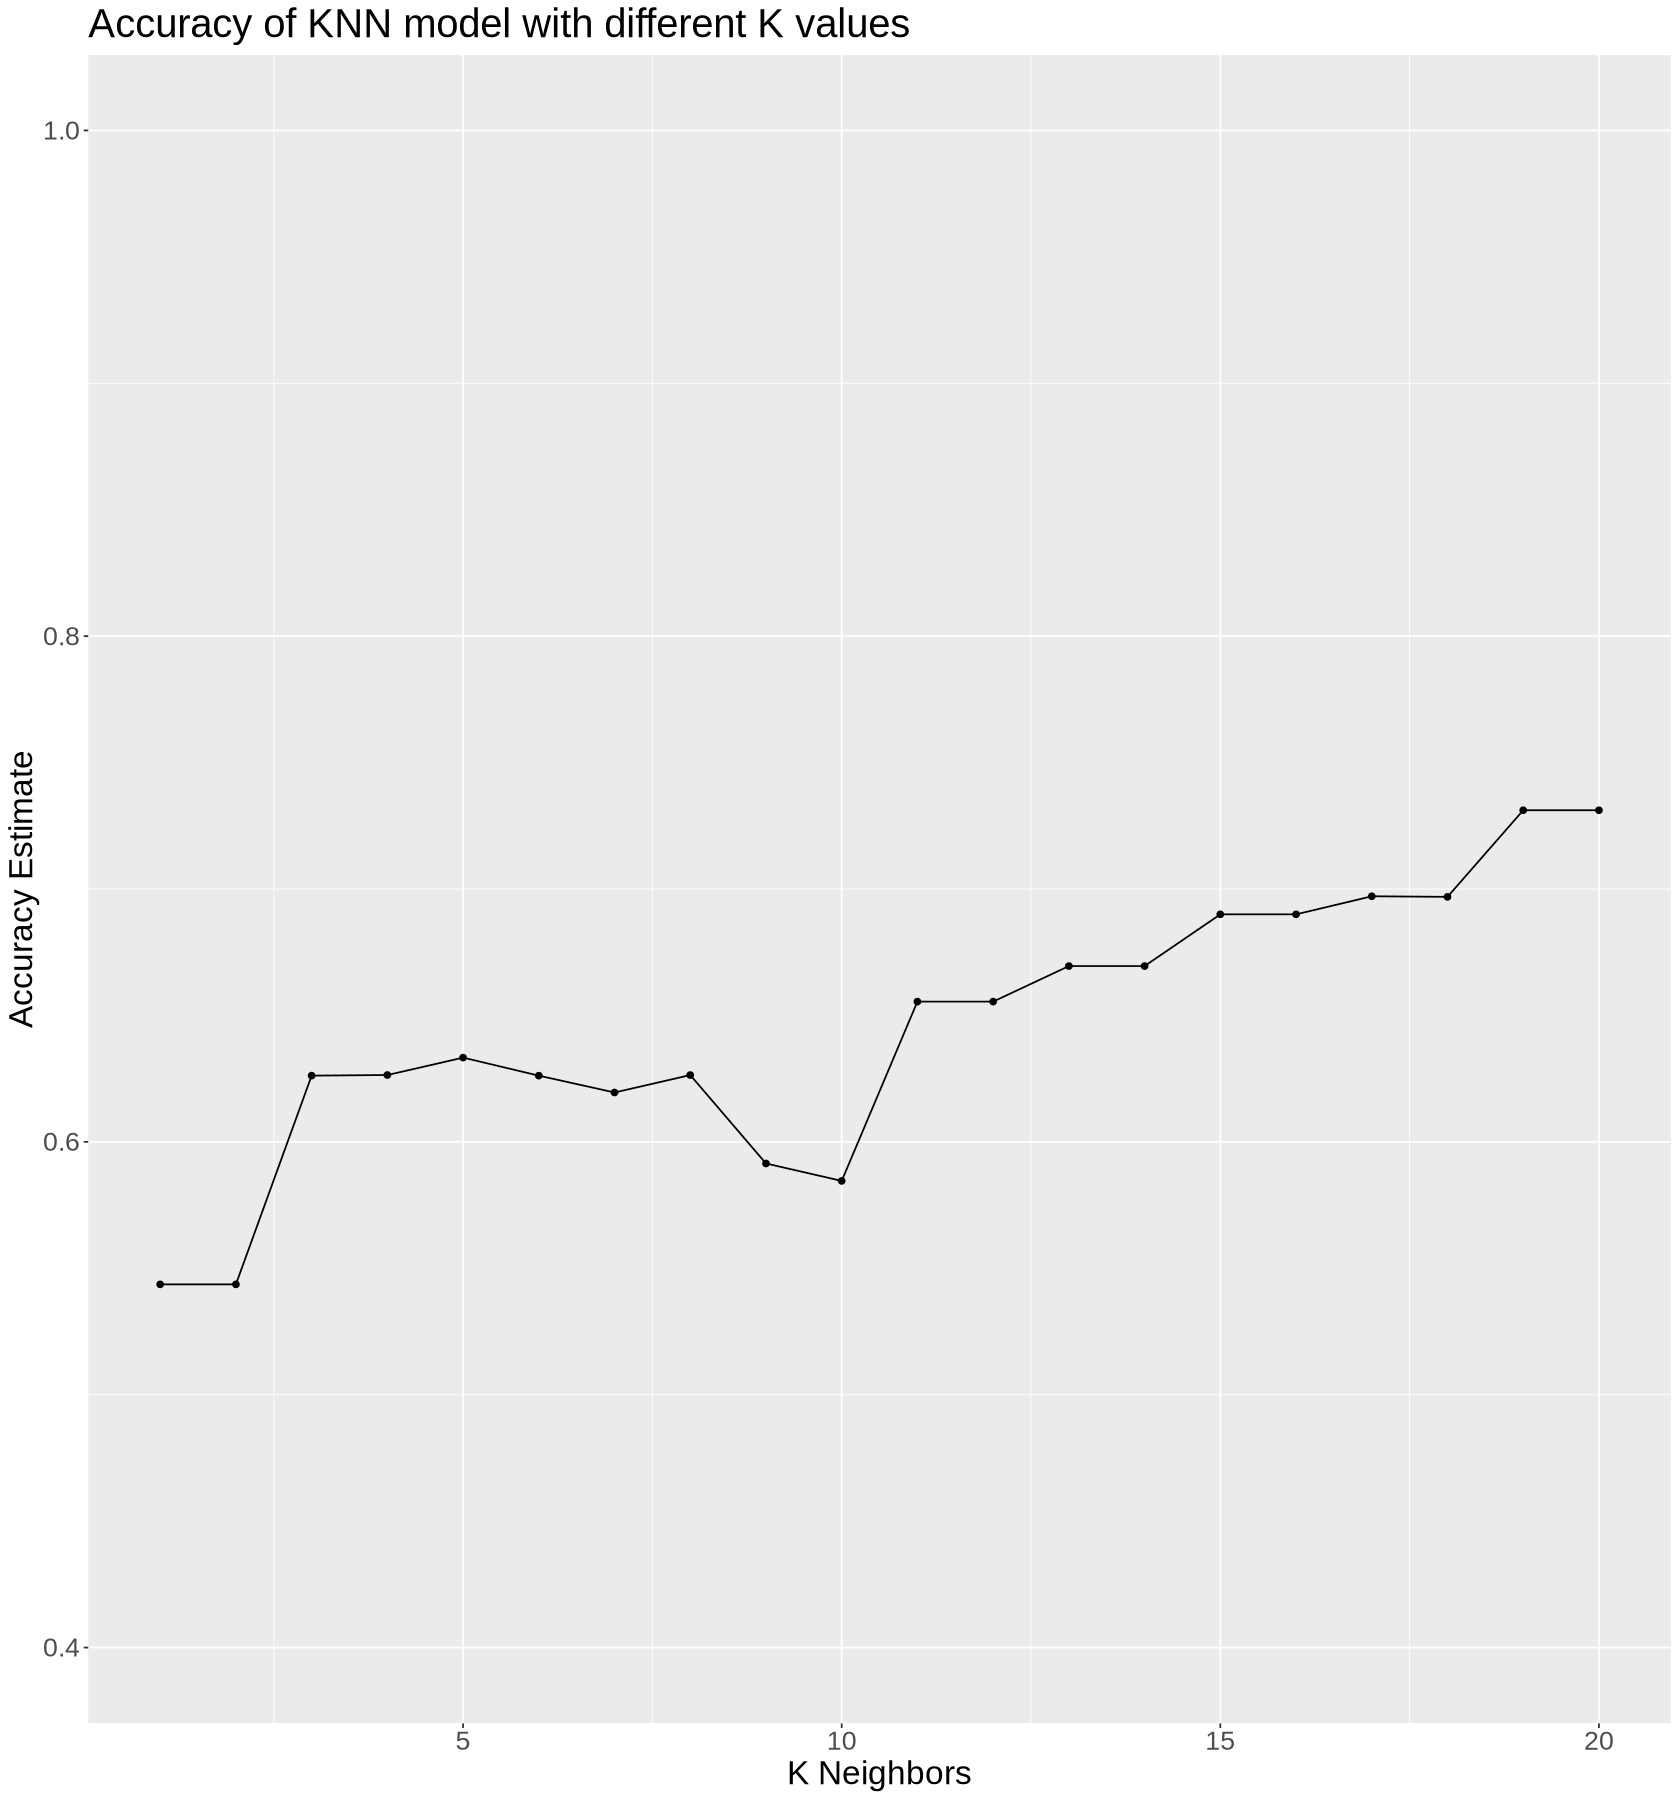

In [334]:
options(repr.plot.width = 14, repr.plot.height = 15)
accuracy_versus_k_plot <- ggplot(accuracies_per_k, aes(x = neighbors, y = mean))+
      geom_point() +
      geom_line() +
      labs(x = "K Neighbors", y = "Accuracy Estimate") +
      scale_x_continuous(breaks = seq(0, 50, by = 5)) +  # adjusting the x-axis
      scale_y_continuous(limits = c(0.4, 1.0)) + # adjusting the y-axis
      theme(text = element_text(size = 20)) +
      ggtitle("Accuracy of KNN model with different K values")

accuracy_versus_k_plot

**Figure 1:** Accuracy of KNN model across different K values (K = 1:20, 5-fold)


**Changing the max K value**

As observed in the plot above, the accuracy increases with increasing K and eventually levels off. This suggests that very small K values may be too sensitive to noise (overfitting) while larger K values may be generalizing too much, making predictions less sensitive to important patterns. In the plot, there comes a point (a peak where K value with the highest accuracy) where increasing the K value would not make much of an impact with the accuracy of the model. For our analysis, we must find the K with the highest accuracy because that is the optimal K for our model.

To find the K with the highest accuracy, we can run the following code:

In [335]:
slice_max(accuracies_per_k, mean, n = 1)

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
19,accuracy,binary,0.7311494,5,0.005037841,Preprocessor1_Model19
20,accuracy,binary,0.7311494,5,0.005037841,Preprocessor1_Model20


From the plot earlier, we can see that the model accuracy doesn't change much after it reaches K value with the highest accuracy. The table above shows K values with the highest accuracy. But, we are picking K = 19 because smaller K can be more sensitive to local patterns. So, we can use K = 19 to train our model. 

**Re-training KNN model with K = 19** 

We can now use K = 19 to re-train our model. We have to re-write the `knn_spec` with our new K value and fit that with training data. 

In [336]:
set.seed(2019)

new_knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbor = 19)|>
    set_engine("kknn")|>
    set_mode("classification")

new_fit_players_train <- workflow () |>
    add_recipe(players_recipe)|>
    add_model(new_knn_spec)|>
    fit(data = players_train)

new_fit_players_train

══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
2 Recipe Steps

• step_scale()
• step_center()

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(19,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.2896552
Best kernel: rectangular
Best k: 19

**Testing our re-trained KNN model with our testing set**

Using bind_cols() gives us a prediction column on `players_test` observations using our trained KNN model and binds that beside the original`players_test`dataframe. So, we can see both predicted values(`.pred_class` column) made by KNN model for the testing data and actual values on the original testing dataset (`subscribe` column) side-by-side.

In [337]:
set.seed(2019)

players_test_predictions <- predict(new_fit_players_train, players_test) |>
       bind_cols(players_test) 
players_test_predictions

.pred_class,subscribe,played_hours,age
<fct>,<fct>,<dbl>,<dbl>
TRUE,TRUE,0,17
TRUE,TRUE,0,19
TRUE,FALSE,0,21
⋮,⋮,⋮,⋮
TRUE,FALSE,0.2,17
TRUE,TRUE,32.0,22
FALSE,TRUE,0.1,44


**Calculating Accuracy of Model**

Now, we can calculate how accurate our model is with predicting whether someone will subscribe to gaming newsletters based on age and number of hours played. Accuracy can tell us whether age and number of hours played are useful in identifying who subscribes and who doesn't. Shown below, our model has 73% accuracy of predicting whether someone will subscribe based on age and number of hours played. 

In [338]:
players_prediction_accuracy <- players_test_predictions |>
        metrics(truth = subscribe, estimate = .pred_class)|>
        filter(.metric == "accuracy")
        
players_prediction_accuracy

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.7346939


**Table 2:** Summary of KNN Model Accuracy (1 × 3 columns).

**Using Precision and Recall**

Accuracy can be misleading. Accuracy doesn't tell us which class is being predicted well. If your model always predicts that someone will not subscribe and a lot of your data contains players who did not subscribe, your model will have a high accuracy. But, we don't know how well the model can catch those ones who did subscribe. We are only accurate at predicting non-subscribers. For game developers, knowing which demographic of people are likely to subscribe can be more meaningful. In our case, we must find a way to know whether our model can predict for actual subscribers (i.e., catch those who did subscribe). We can do this using Precision and Recall.

Precision is useful when false positives are costly (you don’t want to wrongly assume someone will subscribe). Recall is useful when missing real positives is bad (you want to catch all potential subscribers). If our goal is to identify subscribers (e.g., to offer them a deal), we likely care more about recall — catching as many as possible. If our goal is to avoid bothering people who won’t subscribe, we might care more about precision.

Below is the code to run to calculate Precision and Recall on our model's performance:

In [339]:
# Make sure `subscribe` is a factor with the positive class listed first.
# In our case, the positive class is listed first, first observation is TRUE for `subscribe` and our truth = subscribe.

players_test_pred_precision <- players_test_predictions |>
  precision(truth = subscribe, estimate = .pred_class)

players_test_pred_recall <- players_test_predictions |>
  recall(truth = subscribe, estimate = .pred_class)

players_test_pred_precision
players_test_pred_recall


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,0.5


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.07692308


**Table 3:** Summary of Precision and Recall Performance of KNN Model (1 row × 3 columns)

**Is our model good?**

Our precision is 0.50 which means that if the model does predict someone will subscribe, it is right 50% of the time. Our recall is 0.08 which means our model only catches 8% of the actual subscribers. It misses 92% of them. If catching many subscribers as much as possible is more important (high recall), then our model requires a lot of improvement. 

# **Discussion** 
**Summary of our Results**

Using KNN (K Nearest Neighbours) Classification model, we tried to predict whether a play would subscribe based on their age and number of hours played. We tuned for several K values (from 1 to 20) and chose the K value (K = 19) that provided us the highest accuracy (73%). However, the precision (50%) and recall (8%) scores of our model were low. This means our model did not do well catching players who actually subscribed. 

We expected variables like age and number of hours played might be good predictors of whether someone will be a subscriber. However, the low recall implies that the model is not good at predicting for the subscribing class. This could be due to many reasons like class imbalance or the predictors not being strong indicators of subscription behaviour.


**Impact of our Findings**

Our findings show that even with high accuracy of model, it can still fail at detecting a certain class (in this case, those who subscribed). This can lead to poor performance in the real-world setting like gaming events and marketing campaigns where community engagement is crucial. 



**Future Questions**

    - Would including more player characteristics (like level of experience, gender) improve our model's predictive
      performance?
    - Can we use another classification model to improve our prediction? Maybe, they'll handle class imbalances better


